In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import yfinance as yf

In [9]:
from datetime import datetime, timedelta

end_date = datetime.now()
start_date = end_date - timedelta(days=5*365) # Approximately 5 years ago

reg_data = yf.download('GOOGL', start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

/tmp/ipykernel_1343/489889343.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  reg_data = yf.download('GOOGL', start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
[*********************100%***********************]  1 of 1 completed


In [11]:
reg_data.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2021-09-29,133.087067,135.858198,132.603176,135.688804,30848000
2021-09-30,132.415955,134.264862,132.297091,132.995946,37996000
2021-10-01,135.255951,135.619995,132.809232,133.180198,35360000
2021-10-04,132.399628,134.678933,129.814728,134.678933,51202000
2021-10-05,134.740814,135.930996,132.777502,132.777502,32404000


# **Coorelation** **Matrix**

In [13]:
corr_matrix = reg_data.corr()
corr_matrix

,Price,Close,High,Low,Open,Volume
,Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Price,Ticker,,,,,
Close,GOOGL,1.000000,0.999703,0.999718,0.999273,-0.045120
High,GOOGL,0.999703,1.000000,0.999650,0.999681,-0.037075
Low,GOOGL,0.999718,0.999650,1.000000,0.999649,-0.052243
Open,GOOGL,0.999273,0.999681,0.999649,1.000000,-0.043150
Volume,GOOGL,-0.045120,-0.037075,-0.052243,-0.043150,1.000000


# Pair Plot With Regression Lines

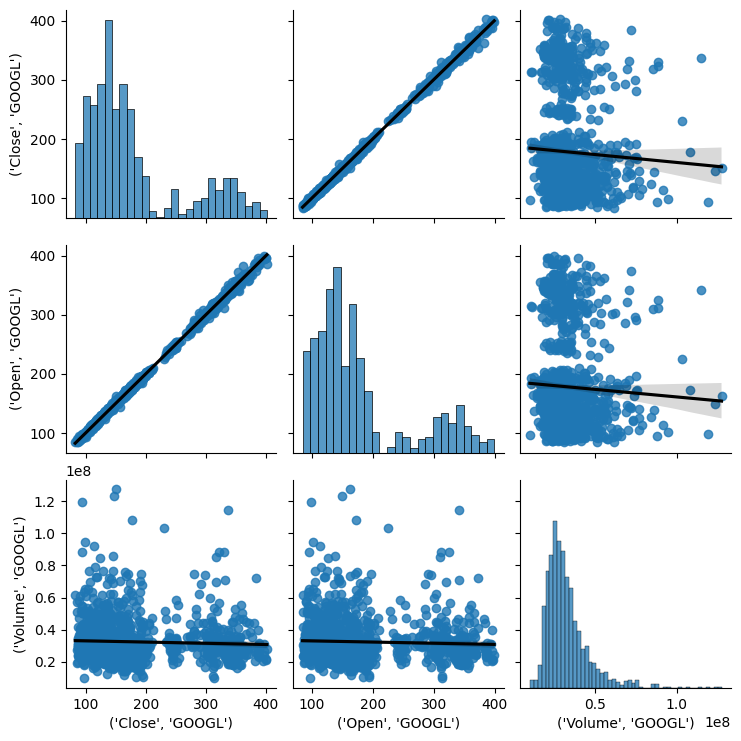

In [16]:
sns.pairplot(reg_data[['Close','Open','Volume']],kind='reg',plot_kws={'line_kws':{'color':'black'}})
plt.show()

# **Define Dependent Variable**

In [17]:
y = reg_data['Close']

# Prepare Independent Variable

In [18]:
x = reg_data[['Open','Volume']]

# Add constant to independent Variable

In [19]:
x = sm.add_constant(x)

# OLS Model

In [20]:
model = sm.OLS(y, x)

# Fit The Model

In [21]:
result = model.fit()

In [22]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  GOOGL   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.304e+05
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:15:24   Log-Likelihood:                -3186.2
No. Observations:                1253   AIC:                             6378.
Df Residuals:                    1250   BIC:                             6394.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4552    